In [1]:
import numpy as np
import io
import ipywidgets as widgets
from IPython.display import display
from PIL import Image
import matplotlib.pyplot as plt
import time


In [2]:
# 1. Import PYNQ's memory allocation tool
from pynq import Overlay, allocate
overlay = Overlay('design_1.bit')
dma = overlay.axi_dma_0 # Accessing the DMA controller via the overlay


In [3]:
print(overlay.ip_dict.keys())


dict_keys(['axi_dma_0', 'processing_system7_0'])


In [4]:
from ipywidgets import FileUpload
from IPython.display import display
from PIL import Image
import io

# Create upload widget
upload = FileUpload(
    accept='.jpg,.jpeg,.png,.bmp',
    multiple=False
)

display(upload)

FileUpload(value={}, accept='.jpg,.jpeg,.png,.bmp', description='Upload')

Image size: (612, 384)
Image mode: RGB


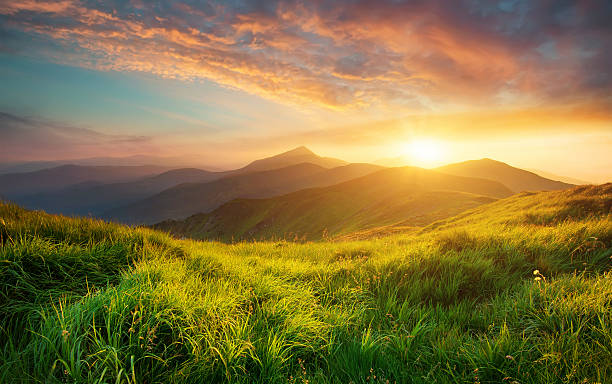

In [19]:
# Get uploaded file
filename = next(iter(upload.value))
file_data = upload.value[filename]['content']

# Open image
img = Image.open(io.BytesIO(file_data)).convert("RGB")

print("Image size:", img.size)
print("Image mode:", img.mode)

display(img)

In [20]:
rgb = np.array(img)

R = rgb[:, :, 0]
G = rgb[:, :, 1]
B = rgb[:, :, 2]

gray = (
    0.299 * R +
    0.587 * G +
    0.114 * B
).astype(np.uint8)

gray_img = Image.fromarray(gray)

In [21]:
R = rgb[:, :, 0].astype(np.uint32)
G = rgb[:, :, 1].astype(np.uint32)
B = rgb[:, :, 2].astype(np.uint32)

pixels32 = (R << 16) | (G << 8) | B

# Convert 2-D image to 1-D stream
pixels32 = pixels32.reshape(-1)

print("Number of pixels:", len(pixels32))
print("First pixel: 0x%08X" % pixels32[0])

Number of pixels: 235008
First pixel: 0x006D5450


In [22]:
print(hex(R[0][0]),hex(G[0][0]),hex(B[0][0]))

0x6d 0x54 0x50


In [23]:
pixels32.shape

(235008,)

In [24]:
img.size[0]*img.size[1]

235008

In [25]:
height, width,_= rgb.shape
print(height,width)

384 612


In [26]:
rgb.shape

(384, 612, 3)

In [27]:
in_buffer = allocate(shape=(height* width), dtype=np.uint8)
out_buffer = allocate(shape=(height* width), dtype=np.uint8)
in_buffer[:] = pixels32
in_buffer.flush()

In [28]:

# The DMA controller reads the physical address automatically under the hood
dma.sendchannel.transfer(in_buffer)  # Streams components out of PSRAM into FPGA PL
dma.recvchannel.transfer(out_buffer) # FPGA streams processed components back into PSRAM

# 4. Wait for the hardware stream transaction to complete
dma.sendchannel.wait()
dma.recvchannel.wait()

# 5. Invalidate the CPU cache before reading back 
# This forces the CPU to read the new data from physical RAM instead of stale cache
out_buffer.invalidate()

In [29]:
out_buffer.shape
pynq_rgb2gray = out_buffer.reshape((height, width))

In [30]:
pynq_rgb2gray.shape

(384, 612)

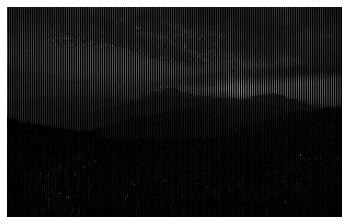

In [31]:
import matplotlib.pyplot as plt

plt.imshow(pynq_rgb2gray, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()